# RQ4

## Setup

* Follow the instructions on ```Readme.md``` 
* Inside the *pipeline* folder, run ```python -m src.rq4``` 
* Tested models: ```'microsoft/codebert-base', 'Salesforce/codet5-base'```
* Supported languages: ```'python', 'java' , 'cs'```
* Results are saved on ```results/RQ4```

## Datasets

In [5]:
from src.config import *

In [6]:
import json
import numpy as np
with open(FILTERED_PATH_TESTS) as f:
    data = json.load(f)

all_scores = []
for entry in data:
    for clone in entry.get("clones", []):
        scores = clone.get("metrics", {}).get("codebleu", {})
        for k, v in scores.items():
            if k != "originalcode":
                all_scores.append(v)

all_scores = np.array(all_scores)
print(f"min:    {all_scores.min():.3f}")
print(f"max:    {all_scores.max():.3f}")
print(f"mean:   {all_scores.mean():.3f}")
print(f"median: {np.median(all_scores):.3f}")
print(f"p25:    {np.percentile(all_scores, 25):.3f}")
print(f"p75:    {np.percentile(all_scores, 75):.3f}")
print(f"p90:    {np.percentile(all_scores, 90):.3f}")

min:    0.001
max:    1.000
mean:   0.365
median: 0.334
p25:    0.232
p75:    0.460
p90:    0.614


In [7]:
import json
import os
from statistics import mean, stdev

json_files = [
     KAMINO_LD_DATASET,
     KAMINO_MD_DATASET,
     KAMINO_HD_DATASET
]

def count_clones_in_json(file_path):
    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    clone_counts = [len(entry.get("clones", [])) for entry in data]
    
    total  = sum(clone_counts)
    mn     = min(clone_counts) if clone_counts else 0
    mx     = max(clone_counts) if clone_counts else 0
    avg    = mean(clone_counts) if clone_counts else 0
    std    = stdev(clone_counts) if len(clone_counts) > 1 else 0

    print(f"\n📁 {file_path}")
    print(f"  Total clones : {total}")
    print(f"  Entries      : {len(data)}")
    print(f"  Min / entry  : {mn}")
    print(f"  Max / entry  : {mx}")
    print(f"  Avg / entry  : {avg:.2f}")
    print(f"  Std / entry  : {std:.2f}")

# Analyze all files

initial_count = None
for i, json_file in enumerate(json_files, 1):
    count_clones_in_json(json_file)



📁 ../results/RQ4/datasets/bigcodebench_clone_dataset_ld.json
  Total clones : 5332
  Entries      : 514
  Min / entry  : 1
  Max / entry  : 56
  Avg / entry  : 10.37
  Std / entry  : 9.78

📁 ../results/RQ4/datasets/bigcodebench_clone_dataset_md.json
  Total clones : 7119
  Entries      : 834
  Min / entry  : 1
  Max / entry  : 40
  Avg / entry  : 8.54
  Std / entry  : 6.24

📁 ../results/RQ4/datasets/bigcodebench_clone_dataset_hd.json
  Total clones : 1477
  Entries      : 862
  Min / entry  : 1
  Max / entry  : 15
  Avg / entry  : 1.71
  Std / entry  : 1.54


In [8]:
import json
from itertools import combinations 

def count_positive_pairs(dataset, dataset_Name):
    with open(dataset, "r", encoding="utf-8") as f:
        data = json.load(f)

    seen_pairs = set()
    positive_pairs = 0

    for entry in data:

        clones = entry.get("clones", [])

        # Only consider entries with at least 2 clones
        if len(clones) < 2:
            continue

        # Clone-clone pairs
        for c1, c2 in combinations(clones, 2):

            code1 = c1["code"]
            code2 = c2["code"]

            key = tuple(sorted([code1, code2]))

            if key not in seen_pairs:
                seen_pairs.add(key)
                positive_pairs += 1

    print(
        f"Dataset {dataset_Name} has a total of "
        f"{positive_pairs} positive pairs excluding original_code"
    )

count_positive_pairs(KAMINO_LD_DATASET, "Kamino-LD")
count_positive_pairs(KAMINO_MD_DATASET, "Kamino-MD")
count_positive_pairs(KAMINO_HD_DATASET, "Kamino-HD")

Dataset Kamino-LD has a total of 49546 positive pairs excluding original_code
Dataset Kamino-MD has a total of 43064 positive pairs excluding original_code
Dataset Kamino-HD has a total of 1552 positive pairs excluding original_code


## Results

In [9]:
csv_path = "../results/RQ4/best_results.csv"
rq3_csv_path = "../results/RQ4/rq3_best_results.csv"
PLOT_RESULTS = "../results/RQ4/plots/"

In [10]:
import pandas as pd
import numpy as np

# Load CSV
csv_path = "../results/RQ4/clone_detection.csv"
df = pd.read_csv(csv_path)

THRESHOLD = 0.5        # set to None to disable filtering
SORT_BY = "f1"         # precision | recall | f1 | mcc | None
DESCENDING = True

if THRESHOLD is not None:
    df = df[np.isclose(df["threshold"], THRESHOLD)] 

if SORT_BY is not None:
    df = df.sort_values(by=SORT_BY, ascending=not DESCENDING)


display(
    df[[
        "model",
        "train_dataset",
        "test_dataset",
        "lan", 
        "threshold",
        "f1",
        "mcc",
    ]].round(4).reset_index(drop=True)
)
df.to_csv(csv_path, index=False)

,model,train_dataset,test_dataset,lan,threshold,f1,mcc
0,microsoft/codebert-base,Kamino-LD,GPTCloneBench,csharp,0.5,0.9688,0.9396
1,Salesforce/codet5-base,Kamino-MD,GPTCloneBench,csharp,0.5,0.9654,0.9321
2,microsoft/codebert-base,Kamino-MD,GPTCloneBench,csharp,0.5,0.9649,0.9322
3,Salesforce/codet5-base,Kamino-LD,GPTCloneBench,csharp,0.5,0.9645,0.9322
4,Salesforce/codet5-base,Kamino-HD,GPTCloneBench,csharp,0.5,0.9599,0.9189
5,microsoft/codebert-base,Kamino-HD,GPTCloneBench,csharp,0.5,0.9531,0.9057
6,microsoft/codebert-base,Kamino-MD,GPTCloneBench,python,0.5,0.9360,0.8803
7,microsoft/codebert-base,Kamino-MD,GPTCloneBench,java,0.5,0.9291,0.8638
8,microsoft/codebert-base,Kamino-LD,GPTCloneBench,python,0.5,0.9233,0.8609
9,microsoft/codebert-base,Kamino-LD,GPTCloneBench,java,0.5,0.9233,0.8575


key ('CodeBERT', 'GCB', 'csharp'): (0.964575953323609, 0.9316448186078948)
key ('CodeBERT', 'SCB', 'csharp'): (0.8229426433915213, 0.7262671919357303)
key ('CodeT5', 'GCB', 'csharp'): (0.9602056555269924, 0.9213075188889268)
key ('CodeT5', 'SCB', 'csharp'): (0.8328304164152082, 0.7227470884254353)
key ('CodeBERT', 'GCB', 'java'): (0.9274479240470456, 0.8557450482422938)
key ('CodeBERT', 'SCB', 'java'): (0.8136574074074074, 0.7018092426208252)
key ('CodeT5', 'GCB', 'java'): (0.9070398997284312, 0.8120961883466671)
key ('CodeT5', 'SCB', 'java'): (0.8040426726558114, 0.6646849068254909)
key ('CodeBERT', 'GCB', 'python'): (0.9217454020915976, 0.8465697380173709)
key ('CodeBERT', 'SCB', 'python'): (0.8311833987661245, 0.716062623931051)
key ('CodeT5', 'GCB', 'python'): (0.8778821520068316, 0.7486328648511063)
key ('CodeT5', 'SCB', 'python'): (0.8360995850622407, 0.6857798510581543)


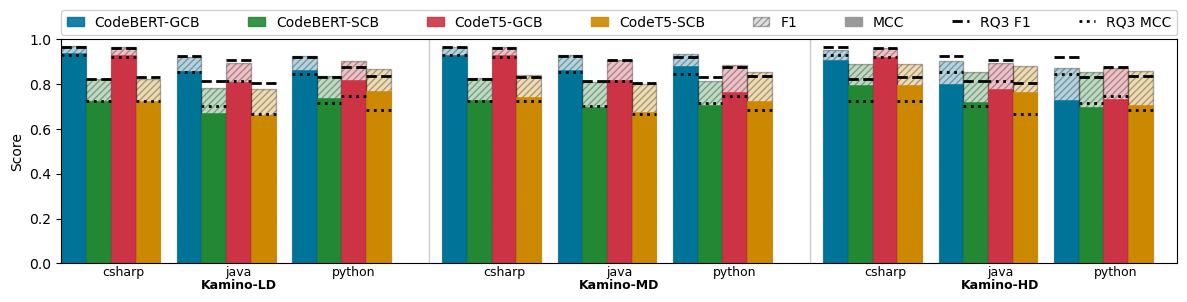

In [11]:
import matplotlib.lines as mlines
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

df = pd.read_csv(csv_path)
df = df[df["model"] != "model"]

for col in ["f1", "mcc"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["f1", "mcc"])

df["test"] = df["test_dataset"].map({
    "GPTCloneBench": "GCB",
    "SemanticCloneBench": "SCB"
})

df["model"] = df["model"].apply(
    lambda x: "CodeBERT" if "codebert" in x.lower()
    else "CodeT5" if "codet5" in x.lower()
    else x
)

df["variant"] = df["train_dataset"]
order = ["Kamino-LD", "Kamino-MD", "Kamino-HD"]

agg = df.groupby(
    ["model", "test", "variant", "lan"],
    as_index=False
)[["f1", "mcc"]].mean()

combos = [
    ("CodeBERT", "GCB"),
    ("CodeBERT", "SCB"),
    ("CodeT5", "GCB"),
    ("CodeT5", "SCB")
]

color_map = {
    ("CodeBERT", "GCB"): "#007399",
    ("CodeBERT", "SCB"): "#228833",
    ("CodeT5", "GCB"): "#CC3344",
    ("CodeT5", "SCB"): "#CC8800",
}

languages = sorted(df["lan"].dropna().unique())

n_combos = len(combos)
n_lang = len(languages)

bar_w = 0.12
lang_gap = 0.08
variant_gap = 0.25

lang_group_w = n_combos * bar_w
variant_group_w = n_lang * lang_group_w + (n_lang - 1) * lang_gap
variant_origins = np.arange(len(order)) * (variant_group_w + variant_gap)

# baseline from RQ3
df2 = pd.read_csv(rq3_csv_path) 
df2["f1"] = pd.to_numeric(df2["f1"], errors="coerce")

df2["test"] = df2["test_dataset"].map({
    "GPTCloneBench": "GCB",
    "SemanticCloneBench": "SCB"
})
df2["model"] = df2["model"].apply(
    lambda x: "CodeBERT" if "codebert" in x.lower()
    else "CodeT5" if "codet5" in x.lower()
    else x
)

baseline_agg = df2.groupby(["model", "test", "lan"], as_index=False)[["f1", "mcc"]].mean()
baseline_map = {
    (row.model, row.test, row.lan): (row.f1, row.mcc)
    for row in baseline_agg.itertuples()
}

# Check a specific lookup
for lang in languages:
    for combo in combos:
        key = (combo[0], combo[1], lang)
        print(f"key {key}: {baseline_map.get(key, 'MISSING')}")
fig, ax = plt.subplots(figsize=(12, 3.5)) 
for vi, variant in enumerate(order):
    v_origin = variant_origins[vi]
    lang_centers = []

    for li, lang in enumerate(languages):
        lang_origin = v_origin + li * (lang_group_w + lang_gap)
        lang_centers.append(lang_origin + lang_group_w / 2)

        for ci, (model, test) in enumerate(combos):
            color = color_map[(model, test)]
            pos = lang_origin + ci * bar_w

            g = agg[
                (agg["model"] == model) &
                (agg["test"] == test) &
                (agg["lan"] == lang) &
                (agg["variant"] == variant)
            ]

            f1_val  = g["f1"].values[0]  if len(g) else np.nan
            mcc_val = g["mcc"].values[0] if len(g) else np.nan

            ax.bar(pos, f1_val, bar_w,
                   color=color, alpha=0.3,
                   edgecolor="black", linewidth=1, hatch="/////")

            ax.bar(pos, mcc_val, bar_w,
                   color=color, alpha=1,
                   edgecolor=color, linewidth=0.4)

    variant_center = v_origin + variant_group_w / 2
   

    for li, lang in enumerate(languages):
        lang_origin = v_origin + li * (lang_group_w + lang_gap)

        for ci, (model, test) in enumerate(combos):
            key = (model, test, lang)
            if key not in baseline_map:
                continue

            y = baseline_map[key]
            color = color_map[(model, test)]
            pos = lang_origin + ci * bar_w

            f1_base, mcc_base = baseline_map[key]

            ax.hlines(y=f1_base, xmin=pos - bar_w/2, xmax=pos + bar_w/2,
                    colors="black", linewidth=2, linestyles="dashed", zorder=5)

            ax.hlines(y=mcc_base, xmin=pos - bar_w/2, xmax=pos + bar_w/2,
                    colors="black", linewidth=2, linestyles="dotted", zorder=5)

    for lang, lc in zip(languages, lang_centers):
        ax.text(lc, -0.01, lang,
                transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=9, color="black")

    ax.text(variant_center, -0.07, variant,
            transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9, fontweight="bold")

    for li in range(1, n_lang):
        sx = v_origin + li * (lang_group_w + lang_gap) - lang_gap / 2 

for vi in range(1, len(order)):
    sx = variant_origins[vi] - variant_gap / 2
    ax.axvline(sx, color="gray", linewidth=1, linestyle="-", alpha=0.4)

ax.set_xticks([])
ax.tick_params(axis="x", length=0)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="x", alpha=0)
ax.set_xlim(-bar_w * 0.5, variant_origins[-1] + variant_group_w + bar_w * 0.5)

color_patches = [
    mpatches.Patch(facecolor=color_map[k], alpha=0.9, edgecolor=color_map[k],
                   label=f"{k[0]}-{k[1]}")
    for k in combos
]

hatch_patches = [
    mpatches.Patch(facecolor="#999", alpha=0.3, hatch="/////",
                   edgecolor="black", linewidth=1, label="F1"),
    mpatches.Patch(facecolor="#999", alpha=1, edgecolor="#999", label="MCC"),
]
f1_baseline = mlines.Line2D([], [], color="black", linewidth=2, linestyle="dashed", label="RQ3 F1")
mcc_baseline = mlines.Line2D([], [], color="black", linewidth=2, linestyle="dotted", label="RQ3 MCC")

ax.legend(
    handles=color_patches + hatch_patches + [f1_baseline, mcc_baseline], 
    ncol=8, 
    loc="lower left",
    bbox_to_anchor=(0, 1.02, 1, 0.1),
    mode="expand",
    borderaxespad=0,
    framealpha=0.9,
    handlelength=1.2,
)

ax.set_xlim(-bar_w * 0.5, variant_origins[-1] + variant_group_w + bar_w * 0.5)

# Remove tight_layout + subplots_adjust, use this instead:
fig.subplots_adjust(left=0.06, right=0.99, top=0.82, bottom=0.18)

pdf_path = os.path.join(PLOT_RESULTS, "RQ4Results.pdf")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np


# Load RQ4 data

df_rq4 = pd.read_csv(csv_path)

# Remove duplicated header rows if present
df_rq4 = df_rq4[df_rq4["model"] != "model"]

# Numeric conversion
for col in ["f1", "mcc"]:
    df_rq4[col] = pd.to_numeric(df_rq4[col], errors="coerce")

df_rq4 = df_rq4.dropna(subset=["f1", "mcc"])

# Normalize names
df_rq4["test"] = df_rq4["test_dataset"].map({
    "GPTCloneBench": "GCB",
    "SemanticCloneBench": "SCB"
})

df_rq4["model"] = df_rq4["model"].apply(
    lambda x: "CodeBERT" if "codebert" in x.lower()
    else "CodeT5" if "codet5" in x.lower()
    else x
)

df_rq4["variant"] = df_rq4["train_dataset"]


# Aggregate RQ4

rq4_agg = (
    df_rq4.groupby(
        ["model", "test", "variant", "lan"],
        as_index=False
    )[["f1", "mcc"]]
    .mean()
)


# Load RQ3 baseline

df_rq3 = pd.read_csv(rq3_csv_path)

for col in ["f1", "mcc"]:
    df_rq3[col] = pd.to_numeric(df_rq3[col], errors="coerce")

df_rq3 = df_rq3.dropna(subset=["f1", "mcc"])

df_rq3["test"] = df_rq3["test_dataset"].map({
    "GPTCloneBench": "GCB",
    "SemanticCloneBench": "SCB"
})

df_rq3["model"] = df_rq3["model"].apply(
    lambda x: "CodeBERT" if "codebert" in x.lower()
    else "CodeT5" if "codet5" in x.lower()
    else x
)

# Aggregate RQ3 baseline
rq3_agg = (
    df_rq3.groupby(
        ["model", "test", "lan"],
        as_index=False
    )[["f1", "mcc"]]
    .mean()
)

# Rename baseline columns
rq3_agg = rq3_agg.rename(columns={
    "f1": "rq3_f1",
    "mcc": "rq3_mcc"
})


# Merge RQ4 with RQ3

merged = rq4_agg.merge(
    rq3_agg,
    on=["model", "test", "lan"],
    how="left"
)


# Percentage differences

merged["f1_diff_abs"] = merged["f1"] - merged["rq3_f1"]
merged["mcc_diff_abs"] = merged["mcc"] - merged["rq3_mcc"]

merged["f1_diff_pct"] = (
    (merged["f1"] - merged["rq3_f1"])
    / merged["rq3_f1"]
) * 100

merged["mcc_diff_pct"] = (
    (merged["mcc"] - merged["rq3_mcc"])
    / merged["rq3_mcc"]
) * 100


# Pretty printing

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

summary_cols = [
    "model",
    "test",
    "lan",
    "variant",
    "rq3_f1",
    "f1",
    "f1_diff_abs",
    "f1_diff_pct",
    "rq3_mcc",
    "mcc",
    "mcc_diff_abs",
    "mcc_diff_pct",
]

summary = merged[summary_cols].copy()

# Round values
numeric_cols = [
    "rq3_f1", "f1", "f1_diff_abs", "f1_diff_pct",
    "rq3_mcc", "mcc", "mcc_diff_abs", "mcc_diff_pct"
]

summary[numeric_cols] = summary[numeric_cols].round(4)

# Sort for readability
summary = summary.sort_values(
    by=["model", "test", "lan", "variant"]
)

print("\n==============================")
print("RQ4 vs RQ3 Comparison")
print("==============================\n")

print(summary.to_string(index=False))


# Additional statistics


print("\n==============================")
print("Average Percentage Improvement by Variant")
print("==============================\n")

variant_stats = (
    summary.groupby("variant")[["f1_diff_pct", "mcc_diff_pct"]]
    .mean()
    .round(2)
)

print(variant_stats)

print("\n==============================")
print("Average Percentage Improvement by Model")
print("==============================\n")

model_stats = (
    summary.groupby("model")[["f1_diff_pct", "mcc_diff_pct"]]
    .mean()
    .round(2)
)

print(model_stats)

print("\n==============================")
print("Best RQ4 Improvements")
print("==============================\n")

best_f1 = summary.sort_values("f1_diff_pct", ascending=False).head(10)
best_mcc = summary.sort_values("mcc_diff_pct", ascending=False).head(10)

print("\nTop 10 F1 Improvements:\n")
print(best_f1[[
    "model", "test", "lan", "variant",
    "f1_diff_pct"
]].to_string(index=False))

print("\nTop 10 MCC Improvements:\n")
print(best_mcc[[
    "model", "test", "lan", "variant",
    "mcc_diff_pct"
]].to_string(index=False))




RQ4 vs RQ3 Comparison

   model test    lan   variant  rq3_f1     f1  f1_diff_abs  f1_diff_pct  rq3_mcc    mcc  mcc_diff_abs  mcc_diff_pct
CodeBERT  GCB csharp Kamino-HD  0.9646 0.9531      -0.0115      -1.1932   0.9316 0.9057       -0.0259       -2.7838
CodeBERT  GCB csharp Kamino-LD  0.9646 0.9688       0.0042       0.4395   0.9316 0.9396        0.0080        0.8566
CodeBERT  GCB csharp Kamino-MD  0.9646 0.9649       0.0003       0.0343   0.9316 0.9322        0.0006        0.0612
CodeBERT  GCB   java Kamino-HD  0.9274 0.9021      -0.0253      -2.7286   0.8557 0.7983       -0.0574       -6.7081
CodeBERT  GCB   java Kamino-LD  0.9274 0.9233      -0.0042      -0.4504   0.8557 0.8575        0.0017        0.2031
CodeBERT  GCB   java Kamino-MD  0.9274 0.9291       0.0016       0.1765   0.8557 0.8638        0.0081        0.9407
CodeBERT  GCB python Kamino-HD  0.9217 0.8701      -0.0517      -5.6077   0.8466 0.7288       -0.1178      -13.9123
CodeBERT  GCB python Kamino-LD  0.9217 0.9233   